In [9]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import os
import pickle
from PIL import Image,ImageFilter
import warnings
import scipy.optimize as opt
import pyqtgraph as pyqt


In [12]:
def ListofFiles(path):
    filelist=[]
    for root, dirs, files in os.walk(path):
        for file in files:
             filelist.append(os.path.join(root,file))
    return filelist
def getImageValues(Files,EventLimit=1):
    if(type(Files) is list):
        values={}
        count=0
        for file in Files:
            img1=Image.open(file)
            imgArray=np.array(img1)
            values[count]=imgArray
            count+=1
            if(EventLimit==count):
                break
        print(f" {count} frames in dictinary ")
    else:
        img1=Image.open(Files)
        values=np.array(img1)
    return values

In [15]:
user=os.getenv('USER')

Directory="/media/"+user+"/Ilker_SSD/10_07bar_6_21_23"

Folders=["16k_8k_7k","12.57k_4.57k_4k","10.3k_2.3k_2k"]

Path=Directory+"/"+Folders[2]+"/"+Time

Time="14ms"
Images=getImageValues(ListofFiles(Path),-1)

 10000 frames in dictinary 


In [21]:


theImage=np.ones(Images[0].shape)
rangex=100000
if (rangex>len(Images.keys())):
    rangex=len(Images.keys())
for i in range(0,rangex):
    theImage+=Images[i]
theImage=theImage/rangex

PixelShape=theImage.shape

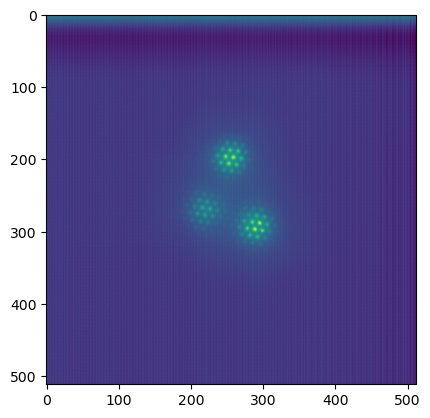

In [24]:
plt.imshow(theImage)

In [47]:
"""
Demonstrates common image analysis tools.

Many of the features demonstrated here are already provided by the ImageView
widget, but here we present a lower-level approach that provides finer control
over the user interface.
"""
from pyqtgraph.jupyter import GraphicsLayoutWidget
import ipywidgets
from IPython.display import display

import pyqtgraph as pg
from pyqtgraph.Qt import QtCore, QtGui
import numpy as np


# Interpret image data as row-major instead of col-major
pg.setConfigOptions(imageAxisOrder='row-major')

pg.mkQApp()
win = GraphicsLayoutWidget(css_width="1024px", css_height="800px")

# A plot area (ViewBox + axes) for displaying the image
p1 = win.addPlot(title="")

# Item for displaying image data
img = pg.ImageItem()
p1.addItem(img)

# Custom ROI for selecting an image region
roi = pg.ROI([0, 100], [100, 100])
roi.addScaleHandle([0.5, 1], [0.5, 0.5])
roi.addScaleHandle([0, 0.5], [0.5, 0.5])
p1.addItem(roi)
roi.setZValue(10)  # make sure ROI is drawn above image

# Isocurve drawing
iso = pg.IsocurveItem(level=0.8, pen='g')
iso.setParentItem(img)
iso.setZValue(250)

# Contrast/color control
hist = pg.HistogramLUTItem()
hist.setImageItem(img)
win.addItem(hist)

# Draggable line for setting isocurve level
isoLine = pg.InfiniteLine(angle=0, movable=True, pen='r')
hist.vb.addItem(isoLine)
hist.vb.setMouseEnabled(y=True) # makes user interaction a little easier
isoLine.setValue(250)
isoLine.setZValue(1) # bring iso line above contrast controls

# Another plot area for displaying ROI data
win.nextRow()
p2 = win.addPlot(colspan=2)
p2.setMaximumHeight(250)


# Generate image data

img.setImage(theImage)
hist.setLevels(theImage.min(), theImage.max())

# build isocurves from smoothed data
#iso.setData(pg.gaussianFilter(data, (2, 2)))

# set position and scale of image
tr = QtGui.QTransform()
img.setTransform(tr.scale(1, 1).translate(-50, 0))

# zoom to fit imageo
p1.autoRange()  


# Callbacks for handling user interaction
def updatePlot():
    global img, roi, data, p2
    selected = roi.getArrayRegion(data, img)
    p2.plot(selected.mean(axis=0), clear=True)

roi.sigRegionChanged.connect(updatePlot)
updatePlot()

def updateIsocurve():
    global isoLine, iso
    iso.setLevel(isoLine.value())

isoLine.sigDragged.connect(updateIsocurve)

def imageHoverEvent(event):
    """Show the position, pixel, and value under the mouse cursor.
    """
    if event.isExit():
        p1.setTitle("")
        return
    pos = event.pos()
    i, j = pos.y(), pos.x()
    i = int(np.clip(i, 0, data.shape[0] - 1))
    j = int(np.clip(j, 0, data.shape[1] - 1))
    val = data[i, j]
    ppos = img.mapToParent(pos)
    x, y = ppos.x(), ppos.y()
    p1.setTitle("pos: (%0.1f, %0.1f)  pixel: (%d, %d)  value: %.3g" % (x, y, i, j, val))

# Monkey-patch the image to use our custom hover function. 
# This is generally discouraged (you should subclass ImageItem instead),
# but it works for a very simple use like this. 
img.hoverEvent = imageHoverEvent




RFBOutputContext()

GraphicsLayoutWidget(css_height='800px', css_width='1024px')
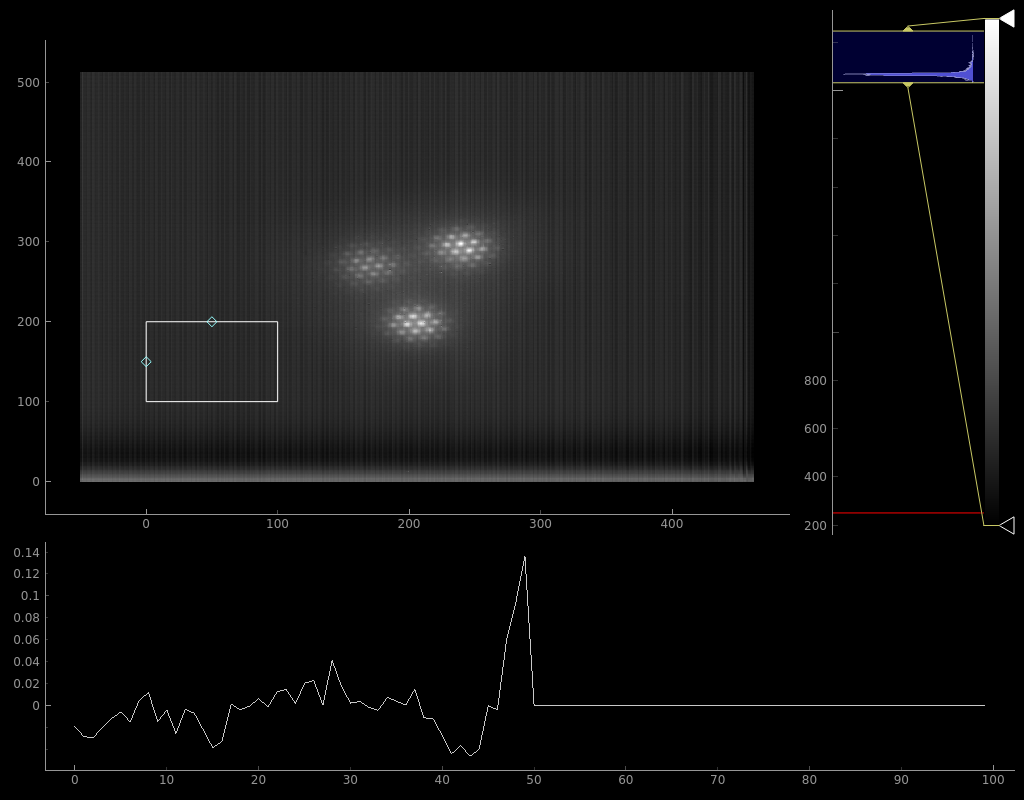

In [48]:
# disable HistogramLUTItem right-click context menus to prevent crashes
hist.vb.setMenuEnabled(False)
hist.gradient.showMenu = lambda ev : None
display(win)